# Assignment 2 2AMM10 2025-2026

## Group: Deep
### Member 1: Wessel Bekx
### Member 2: Quincy Salden
### Member 3: Y.S.P.Veeravalli

In [8]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [9]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train", augment=False):
        self.root = Path(root)
        self.split = split
        self.augment = augment

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        graph = self.graphs[idx]
        if self.augment:
            graph = graph.clone()
            # 1. Random horizontal flip (reflection symmetry)
            if random.random() > 0.5:
                graph.x[:, 0] = -graph.x[:, 0]
            # 2. Random coordinate jittering
            if random.random() > 0.5:
                graph.x = graph.x + torch.randn_like(graph.x) * 0.01
                
        return graph


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train", augment=True)
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test", augment=False)
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

ModuleNotFoundError: No module named 'torch_geometric'

In [ ]:
conda install torch

<Axes: >

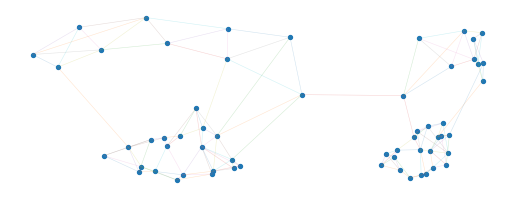

In [3]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [4]:
# Model implementation from scratch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def collate_graphs(batch_list):
    xs = []
    ys = []
    edge_indices = []
    node_offset = 0
    for graph in batch_list:
        xs.append(graph.x)
        ys.append(graph.y)
        edge_indices.append(graph.edge_index + node_offset)
        node_offset += graph.x.size(0)
    
    x_batch = torch.cat(xs, dim=0)
    y_batch = torch.cat(ys, dim=0)
    edge_index_batch = torch.cat(edge_indices, dim=1)
    return x_batch, edge_index_batch, y_batch

class CustomGNNLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.lin_self = nn.Linear(in_features, out_features, bias=False)
        self.lin_neigh = nn.Linear(in_features, out_features, bias=False)
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_self.weight)
        nn.init.xavier_uniform_(self.lin_neigh.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, h, edge_index):
        row, col = edge_index[0], edge_index[1]
        N = h.size(0)
        
        # Compute incoming degrees for each node
        deg = torch.zeros(N, 1, device=h.device)
        deg.index_add_(0, row, torch.ones(edge_index.size(1), 1, device=h.device))
        deg = torch.clamp(deg, min=1.0)
        
        # Aggregate features from neighbors
        neigh_sum = torch.zeros(N, h.size(1), device=h.device)
        neigh_sum.index_add_(0, row, h[col])
        neigh_mean = neigh_sum / deg
        
        # Linear projection + bias
        out = self.lin_self(h) + self.lin_neigh(neigh_mean)
        if self.bias is not None:
            out = out + self.bias
            
        return torch.relu(out)

class DrowsyGNN(nn.Module):
    def __init__(self, in_features=3, hidden_dim=64, num_layers=3, dropout=0.3):
        super().__init__()
        self.layers = nn.ModuleList()
        self.layers.append(CustomGNNLayer(in_features, hidden_dim))
        for _ in range(num_layers - 1):
            self.layers.append(CustomGNNLayer(hidden_dim, hidden_dim))
        
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        h = x
        for layer in self.layers:
            h = layer(h, edge_index)
        
        # Global mean pooling (exactly 60 nodes per graph)
        h_pooled = h.view(-1, 60, h.size(-1)).mean(dim=1)
        
        # Classifier head
        out = self.fc1(h_pooled)
        out = torch.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze(-1)


In [5]:
# Training and evaluation execution
import numpy as np

# Seed everything for final run reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_graphs)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_graphs)

model = DrowsyGNN(in_features=3, hidden_dim=64, num_layers=3, dropout=0.3).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

epochs = 150
train_losses = []
test_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        x, edge_index, y = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE).float()
        optimizer.zero_grad()
        out = model(x, edge_index)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * (y.size(0) / len(train_dataset))
    train_losses.append(total_loss)
    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            x, edge_index, y = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE).float()
            out = model(x, edge_index)
            loss = criterion(out, y)
            test_loss += loss.item() * (y.size(0) / len(test_dataset))
    test_losses.append(test_loss)
    
    if epoch % 10 == 0 or epoch == epochs:
        print(f"Epoch {epoch:03d} | Train Loss: {total_loss:.4f} | Test Loss: {test_loss:.4f}")

# Final Evaluation
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in test_loader:
        x, edge_index, y = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
        out = model(x, edge_index)
        preds = (torch.sigmoid(out) > 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

tp = np.sum((all_preds == 1) & (all_targets == 1))
fp = np.sum((all_preds == 1) & (all_targets == 0))
fn = np.sum((all_preds == 0) & (all_targets == 1))

test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
test_accuracy = np.mean(all_preds == all_targets)

print("\n--- Test Set Metrics ---")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f} (Required Baseline: 0.6)")
print(f"Recall:    {test_recall:.4f} (Required Baseline: 0.6)")


Epoch 010 | Train Loss: 0.4793 | Test Loss: 0.5869
Epoch 020 | Train Loss: 0.3865 | Test Loss: 0.5413
Epoch 030 | Train Loss: 0.3819 | Test Loss: 0.5226
Epoch 040 | Train Loss: 0.3670 | Test Loss: 0.4253
Epoch 050 | Train Loss: 0.3576 | Test Loss: 0.4432
Epoch 060 | Train Loss: 0.3400 | Test Loss: 0.5606
Epoch 070 | Train Loss: 0.3543 | Test Loss: 0.5433
Epoch 080 | Train Loss: 0.4082 | Test Loss: 0.4045
Epoch 090 | Train Loss: 0.3606 | Test Loss: 0.4131
Epoch 100 | Train Loss: 0.3690 | Test Loss: 0.4541
Epoch 110 | Train Loss: 0.4260 | Test Loss: 0.4459
Epoch 120 | Train Loss: 0.3193 | Test Loss: 0.4353
Epoch 130 | Train Loss: 0.3176 | Test Loss: 0.5375
Epoch 140 | Train Loss: 0.3498 | Test Loss: 0.4754
Epoch 150 | Train Loss: 0.3036 | Test Loss: 0.4808

--- Test Set Metrics ---
Accuracy:  0.7600
Precision: 0.8611 (Required Baseline: 0.6)
Recall:    0.6200 (Required Baseline: 0.6)


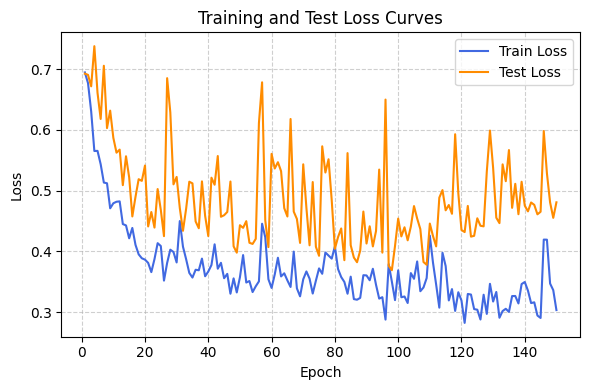

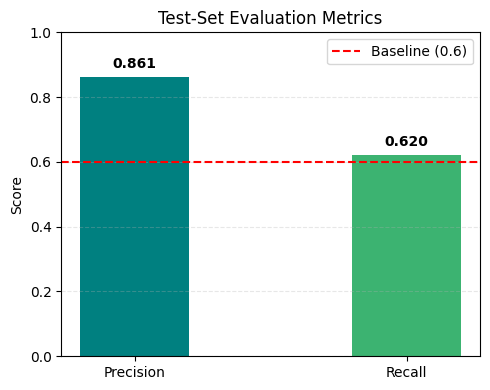

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='royalblue')
plt.plot(range(1, epochs + 1), test_losses, label='Test Loss', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=300)
plt.show()


plt.figure(figsize=(5, 4))
metrics = ['Precision', 'Recall']
values = [test_precision, test_recall]
bars = plt.bar(metrics, values, color=['teal', 'mediumseagreen'], width=0.4)
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5, label='Baseline (0.6)')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.title('Test-Set Evaluation Metrics')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3, axis='y')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300)
plt.show()


# Task 2

In [24]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

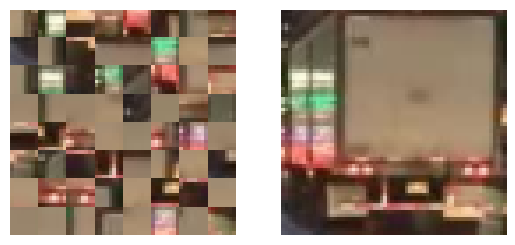

In [25]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [26]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    """
    Splits the image into 8x8 patches and embeds them into a dense vector.
    """
    def __init__(self, in_channels=3, embed_dim=128, patch_size=8):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, 
            embed_dim, 
            kernel_size=patch_size, 
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)        
        x = x.flatten(2)         
        x = x.transpose(1, 2)     
        return x

class PermutationInvariantViT(nn.Module):
    def __init__(self, in_channels=3, embed_dim=128, num_heads=4, num_layers=4, num_classes=8):
        super().__init__()
        
        self.patch_embed = PatchEmbedding(in_channels, embed_dim, patch_size=8)
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=embed_dim * 4,
            dropout=0.3,
            activation='gelu',
            batch_first=True,  
            norm_first=True     
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)     
        x = torch.cat((cls_tokens, x), dim=1)             
        x = self.transformer(x)
        cls_out = x[:, 0, :]                              
        
        cls_out = self.norm(cls_out)
        logits = self.head(cls_out)
        
        return logits

In [27]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch

def train_model(model, train_loader, val_loader=None, epochs=10, lr=3e-4, device='cpu'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    
    train_losses = []
    val_losses = [] 
    
    print("Starting Training...")
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += labels.size(0)
            correct_train += predicted.eq(labels).sum().item()
            
            loop.set_postfix(loss=loss.item(), acc=100.*correct_train/total_train)
            
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        if val_loader is not None:
            model.eval()
            running_val_loss = 0.0
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    running_val_loss += loss.item()
                    
            avg_val_loss = running_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f"--> End of Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
    print("Training Complete!")
    
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='-', color='b', label='Training Loss')
    
    # Only plot validation loss if it was calculated
    if val_loader is not None:
        plt.plot(range(1, epochs + 1), val_losses, marker='s', linestyle='--', color='r', label='Validation Loss')
        
    plt.title("Training and Validation Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Average Cross-Entropy Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return model

def evaluate_and_plot(model, test_loader, device='cpu', dataset_name="Clean"):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate Precision and Recall per class
    precision, recall, _, _ = precision_recall_fscore_support(
        all_labels, all_preds, labels=range(8), zero_division=0
    )
    
    # Calculate Aggregated (Macro Average) Metrics
    agg_precision = np.mean(precision)
    agg_recall = np.mean(recall)
    
    print(f"--- Results for {dataset_name} Test Set ---")
    print(f"Aggregated Precision: {agg_precision:.4f} (Required: >= 0.3)")
    print(f"Aggregated Recall: {agg_recall:.4f} (Required: >= 0.3)\n")
    
    classes = [f"Class {i}" for i in range(8)]
    x = np.arange(len(classes))
    width = 0.35  

    fig1, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(x - width/2, precision, width, label='Precision', color='skyblue')
    ax1.bar(x + width/2, recall, width, label='Recall', color='salmon')
    
    # Red baseline
    ax1.axhline(y=0.3, color='red', linestyle='--', linewidth=2.5, label='Baseline Score (0.3)')

    ax1.set_ylabel('Scores')
    ax1.set_title(f'Per-Class Precision and Recall ({dataset_name} Dataset)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes)
    ax1.legend(loc='upper right')
    ax1.set_ylim([0, 1.05])
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()  
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    
    metrics_names = ['Aggregated\nPrecision', 'Aggregated\nRecall']
    metrics_values = [agg_precision, agg_recall]
    
    bars = ax2.bar(metrics_names, metrics_values, color=['skyblue', 'salmon'], width=0.4)

    # Red baseline
    ax2.axhline(y=0.3, color='red', linestyle='--', linewidth=3, label='Baseline Score (0.3)')

    # Print exact values above the bars
    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

    ax2.set_ylabel('Score')
    ax2.set_title(f'Aggregated Metrics ({dataset_name} Dataset)')
    ax2.set_ylim([0, 1.1]) 
    
    ax2.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show() 
    
    return agg_precision, agg_recall

C:\Users\20213053\AppData\Local\Temp\ipykernel_2704\3881488736.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Using device: cpu
Starting Training...


Epoch 1/40 [Train]: 100%|██████████| 38/38 [00:06<00:00,  6.33it/s, acc=12.7, loss=2.01]


--> End of Epoch 1 | Train Loss: 2.1126 | Val Loss: 2.0696


Epoch 2/40 [Train]: 100%|██████████| 38/38 [00:05<00:00,  6.42it/s, acc=15, loss=2.05]  


...

--> End of Epoch 38 | Train Loss: 1.4538 | Val Loss: 1.6595


Epoch 39/40 [Train]: 100%|██████████| 38/38 [00:06<00:00,  6.07it/s, acc=47, loss=1.83]  


--> End of Epoch 39 | Train Loss: 1.4357 | Val Loss: 1.7274


Epoch 40/40 [Train]: 100%|██████████| 38/38 [00:06<00:00,  6.05it/s, acc=47, loss=1.58]  


--> End of Epoch 40 | Train Loss: 1.4360 | Val Loss: 1.6613
Training Complete!


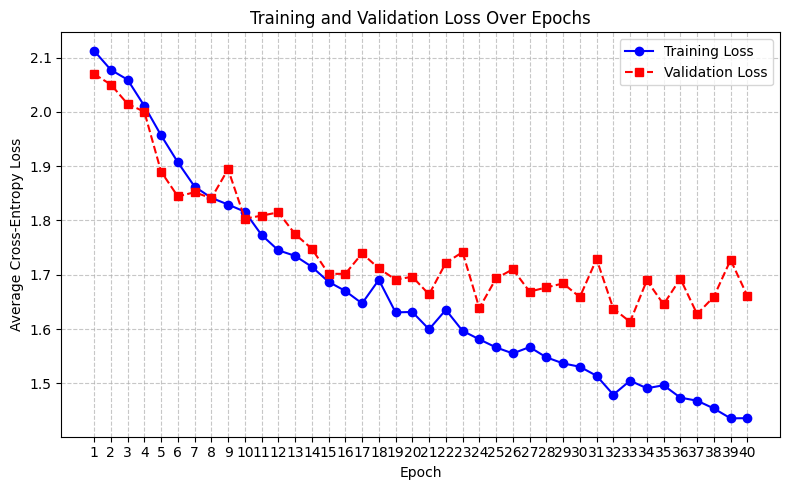


Evaluating on CLEAN Test Set
--- Results for Clean Test Set ---
Aggregated Precision: 0.3900 (Required: >= 0.3)
Aggregated Recall: 0.4042 (Required: >= 0.3)



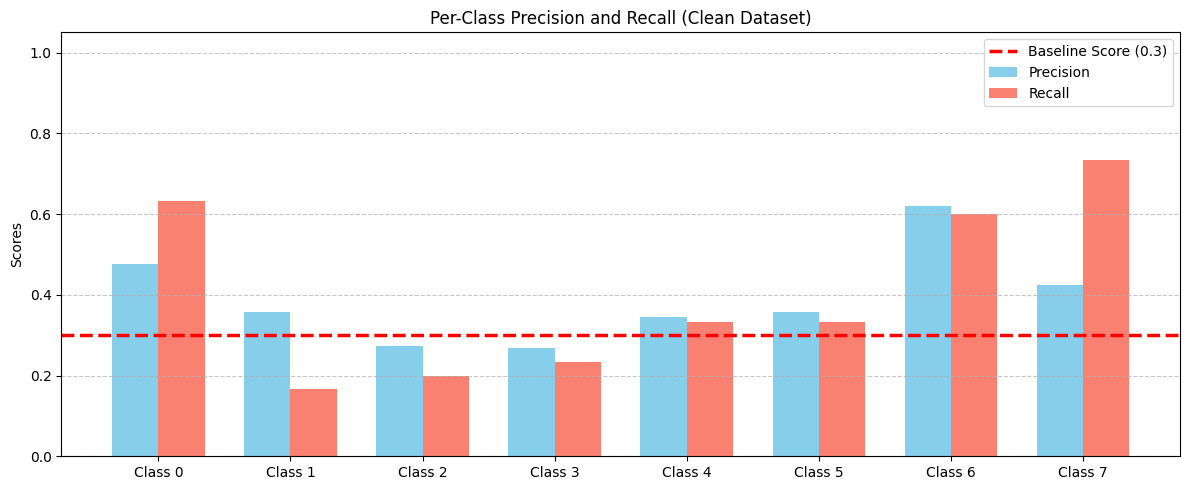

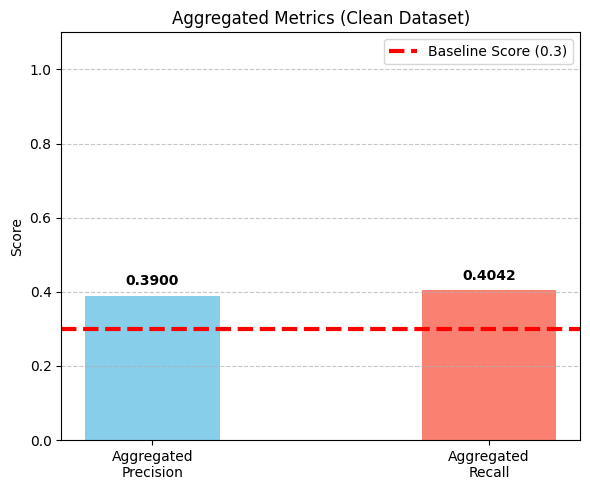


Evaluating on NOISY (PatchShuffle) Test Set
--- Results for Noisy Test Set ---
Aggregated Precision: 0.3900 (Required: >= 0.3)
Aggregated Recall: 0.4042 (Required: >= 0.3)



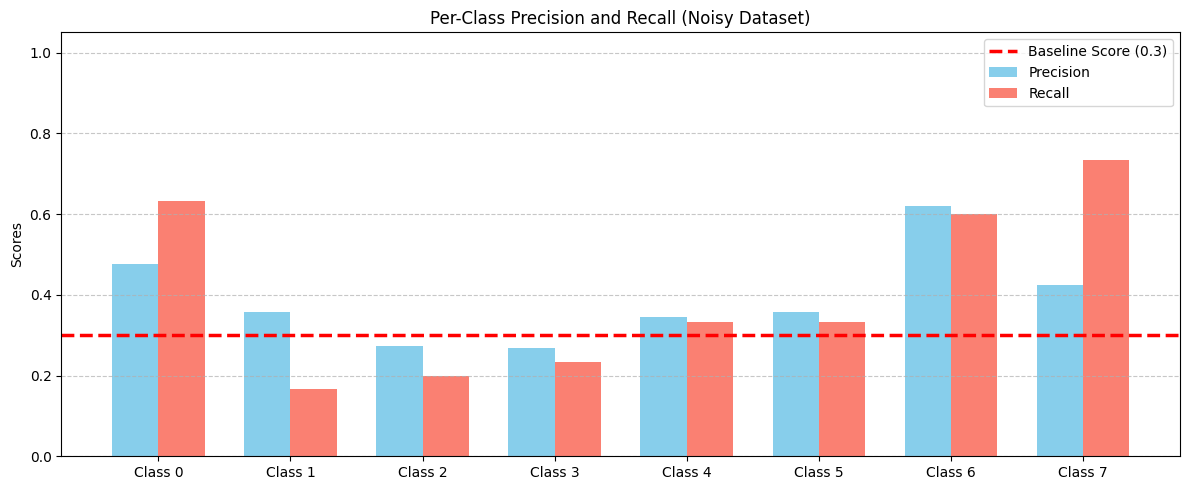

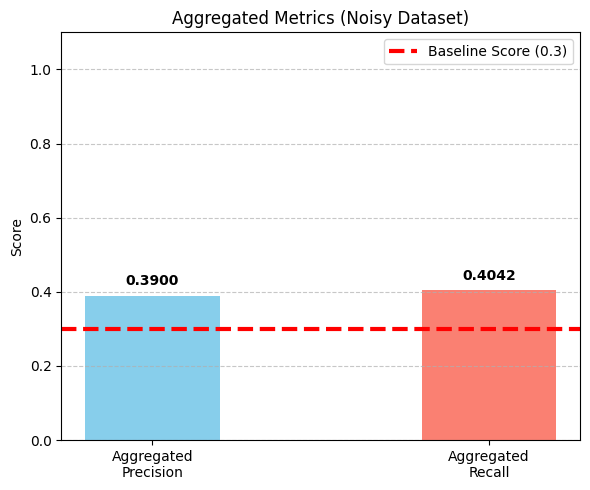


=== Final Aggregate Metrics ===
Noisy Precision: 0.3900 (Baseline to beat: 0.3)
Noisy Recall:    0.4042 (Baseline to beat: 0.3)


In [28]:
from torchvision.transforms import Compose, ToTensor, Resize
from torch.utils.data import DataLoader

# Train on clean images
train_transform = Compose([
    Resize((64, 64)),
    ToTensor()
])

# Evaluate on clean images
test_clean_transform = Compose([
    Resize((64, 64)),
    ToTensor()
])

# Evaluate on corrupted images using the provided PatchShuffle
test_noisy_transform = Compose([
    Resize((64, 64)),
    ToTensor(),
    PatchShuffle(patch_size=8)
])


train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=train_transform,  
)

test_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_clean_transform,  
)

test_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=test_noisy_transform, 
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
clean_test_loader = DataLoader(test_dataset_clean, batch_size=batch_size, shuffle=False)
noisy_test_loader = DataLoader(test_dataset_noisy, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the Permutation-Invariant ViT
model = PermutationInvariantViT(
    in_channels=3, 
    embed_dim=64, 
    num_heads=2, 
    num_layers=2, 
    num_classes=8
)
model = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=clean_test_loader,  
    epochs=40, 
    lr=3e-4, 
    device=device
)
# Evaluate on the clean test set
print("\n" + "="*40)
print("Evaluating on CLEAN Test Set")
print("="*40)
clean_precision, clean_recall = evaluate_and_plot(
    model, clean_test_loader, device=device, dataset_name="Clean"
)

# Evaluate on the noisy test set
print("\n" + "="*40)
print("Evaluating on NOISY (PatchShuffle) Test Set")
print("="*40)
noisy_precision, noisy_recall = evaluate_and_plot(
    model, noisy_test_loader, device=device, dataset_name="Noisy"
)
print("\n=== Final Aggregate Metrics ===")
print(f"Noisy Precision: {noisy_precision:.4f} (Baseline to beat: 0.3)")
print(f"Noisy Recall:    {noisy_recall:.4f} (Baseline to beat: 0.3)")

## Task 3 

In [29]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass




    

In [30]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit_encoder = vit_b_16(weights=weights)

feature_dim = vit_encoder.heads.head.in_features
vit_encoder.heads = nn.Identity()

for param in vit_encoder.parameters():
    param.requires_grad = False

vit_encoder = vit_encoder.to(device)
vit_encoder.eval()

print("feature dimension:", feature_dim)

feature dimension: 768


In [31]:
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

# ViT-B/16 expects 224x224 images normalized with ImageNet statistics
vit_img_transform = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset_vit = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=vit_img_transform,
)

test_dataset_vit = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=vit_img_transform,
)

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=32,
    shuffle=False,
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=32,
    shuffle=False,
)

images, labels = next(iter(train_loader_vit))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [32]:
@torch.no_grad()
def extract_features(encoder, dataloader, device):
    encoder.eval()
    
    all_features = []
    all_labels = []
    
    for images, labels in dataloader:
        images = images.to(device)
        
        features = encoder(images)
        
        all_features.append(features.cpu())
        all_labels.append(labels.cpu())
    
    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    return all_features, all_labels


train_features, train_labels = extract_features(
    vit_encoder,
    train_loader_vit,
    device
)

test_features, test_labels = extract_features(
    vit_encoder,
    test_loader_vit,
    device
)


print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)
print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)

Train features: torch.Size([2400, 768])
Train labels: torch.Size([2400])
Test features: torch.Size([240, 768])
Test labels: torch.Size([240])


In [33]:
from torch.utils.data import TensorDataset, DataLoader

num_classes = 8

linear_probe = nn.Linear(feature_dim, num_classes).to(device)

probe_train_dataset = TensorDataset(train_features, train_labels)
probe_train_loader = DataLoader(probe_train_dataset, batch_size=64, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_probe.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    linear_probe.train()
    total_loss = 0.0
    
    for features, labels in probe_train_loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = linear_probe(features)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
    
    avg_loss = total_loss / len(probe_train_dataset)
    if epoch % 1 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 1.4353
Epoch 2/10 - Loss: 0.9366
Epoch 3/10 - Loss: 0.8058
Epoch 4/10 - Loss: 0.7297
Epoch 5/10 - Loss: 0.6764
Epoch 6/10 - Loss: 0.6333
Epoch 7/10 - Loss: 0.6000
Epoch 8/10 - Loss: 0.5672
Epoch 9/10 - Loss: 0.5426
Epoch 10/10 - Loss: 0.5223


In [34]:
import torch.nn.functional as F

def knn_predict(train_features, train_labels, test_features, k=5):
    # Normalize features so nearest neighbors use cosine similarity
    train_features_norm = F.normalize(train_features, dim=1)
    test_features_norm = F.normalize(test_features, dim=1)
    
    # Similarity: [num_test, num_train]
    similarities = test_features_norm @ train_features_norm.T
    
    # Indices of k nearest train samples for each test sample
    _, knn_indices = similarities.topk(k=k, dim=1)
    
    # Labels of nearest neighbors: [num_test, k]
    knn_labels = train_labels[knn_indices]
    
    # Majority vote
    preds = []
    for labels in knn_labels:
        pred = torch.bincount(labels, minlength=8).argmax()
        preds.append(pred)
    
    return torch.stack(preds)


k = 5
knn_preds = knn_predict(train_features, train_labels, test_features, k=k)

print("kNN predictions:", knn_preds.shape)
print("First 10 predictions:", knn_preds[:10])

kNN predictions: torch.Size([240])
First 10 predictions: tensor([3, 0, 4, 7, 4, 2, 5, 4, 0, 2])


=== Task 3 Comparison: Aggregated Test Metrics ===
Pretrained ViT + Linear Probe | Precision: 0.7325 | Recall: 0.7250
Pretrained ViT + kNN          | Precision: 0.6600 | Recall: 0.6375
Task 2 Scratch ViT            | Precision: 0.3900 | Recall: 0.4042


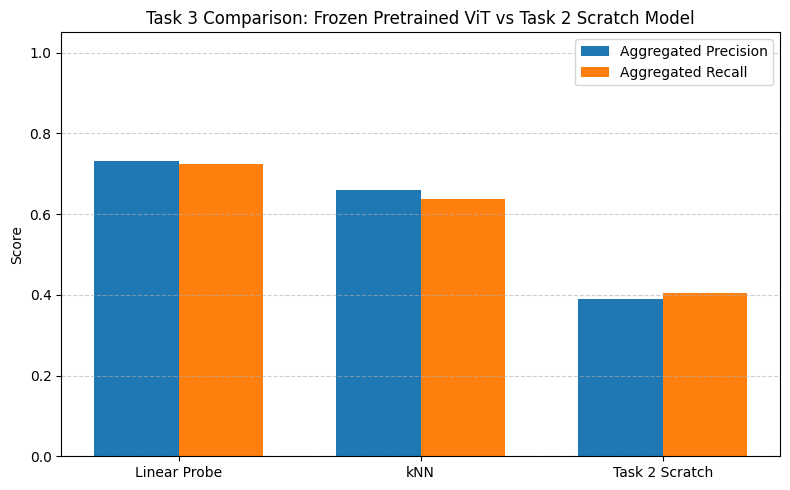

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

def macro_precision_recall(y_true, y_pred, num_classes=8):
    precision, recall, _, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=range(num_classes),
        zero_division=0
    )
    return np.mean(precision), np.mean(recall)


linear_probe.eval()
with torch.no_grad():
    linear_logits = linear_probe(test_features.to(device))
    linear_preds = linear_logits.argmax(dim=1).cpu()

linear_precision, linear_recall = macro_precision_recall(
    test_labels.numpy(),
    linear_preds.numpy()
)


knn_precision, knn_recall = macro_precision_recall(
    test_labels.numpy(),
    knn_preds.numpy()
)


scratch_precision = clean_precision
scratch_recall = clean_recall


# Print results
print("=== Task 3 Comparison: Aggregated Test Metrics ===")
print(f"Pretrained ViT + Linear Probe | Precision: {linear_precision:.4f} | Recall: {linear_recall:.4f}")
print(f"Pretrained ViT + kNN          | Precision: {knn_precision:.4f} | Recall: {knn_recall:.4f}")
print(f"Task 2 Scratch ViT            | Precision: {scratch_precision:.4f} | Recall: {scratch_recall:.4f}")


methods = ["Linear Probe", "kNN", "Task 2 Scratch"]
precisions = [linear_precision, knn_precision, scratch_precision]
recalls = [linear_recall, knn_recall, scratch_recall]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, precisions, width, label="Aggregated Precision")
plt.bar(x + width/2, recalls, width, label="Aggregated Recall")


plt.xticks(x, methods)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Task 3 Comparison: Frozen Pretrained ViT vs Task 2 Scratch Model")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()